In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,15422,-1.883328,-0.623327,0.361952,1.823571,0.279554,-1.169896,-1.202752,0.178698,-1.484234,...,-0.390812,1.333072,1.247922,0.724678,-0.335569,-0.360588,-1.195909,0.592721,32.11,0
1,133739,1.130478,-0.484702,2.631668,-0.210507,-0.326067,1.835858,-1.234177,1.413149,0.355041,...,-1.136737,-0.875618,0.572090,-0.106208,-0.620859,-1.407059,-1.364963,1.423699,43.91,0
2,113109,1.182725,-1.367363,0.811477,0.022025,-0.955141,0.653775,0.183414,1.338705,0.657641,...,-0.218446,1.782544,0.165638,-0.851970,-0.763332,-0.726307,-1.097483,-1.257342,4.80,0
3,75838,-0.474367,-0.036272,-0.918774,-0.562707,-0.496817,0.325786,-1.027912,0.268661,-0.860044,...,1.022482,-1.036836,0.447866,-0.213127,-0.082703,0.861625,-1.074645,0.406988,8.14,0
4,74825,0.521276,-0.268252,-0.410802,-0.191757,0.896767,-0.539804,-0.713140,-0.664155,1.446510,...,-1.925182,-2.263544,-0.912378,-0.004748,0.372799,1.167776,0.730220,0.327678,13.56,0


In [4]:
# check imbalance data
df['Class'].value_counts()

Class
0    19880
1      120
Name: count, dtype: int64

<Axes: xlabel='Class'>

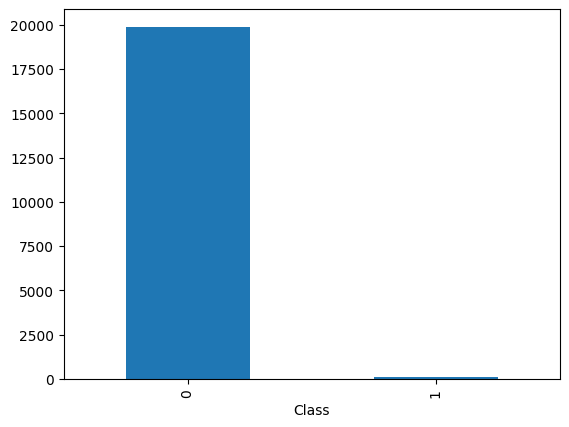

In [5]:
df['Class'].value_counts().plot(kind='bar')

In [6]:
df.shape

(20000, 31)

In [7]:
df = df.sample(n=20000)

df['Class'].value_counts()

Class
0    19880
1      120
Name: count, dtype: int64

# Train model on imbalance dataset

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Calculate classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)

# Calculate accuracy
accuracy = rf_model.score(X_test, y_test)
print("Accuracy:", accuracy)

Confusion Matrix:
[[3978    0]
 [  22    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3978
           1       0.00      0.00      0.00        22

    accuracy                           0.99      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.99      0.99      0.99      4000



c:\Users\DELL\.conda\envs\akhil\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\.conda\envs\akhil\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\.conda\envs\akhil\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.9945


# Apply Sampling Techniques: (RandomeOverSampler)

In [13]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Initialize RandomOverSampler
ros = RandomOverSampler()

# Perform Random Oversampling
X_ros, y_ros = ros.fit_resample(X_train, y_train)

In [14]:
y_ros.value_counts()

Class
0    15902
1    15902
Name: count, dtype: int64

In [15]:

# Initialize the model
rf_model_ros = RandomForestClassifier()

# Train the model on Random Oversampled data
rf_model_ros.fit(X_ros, y_ros)

# Predict on the test set
y_pred_ros = rf_model_ros.predict(X_test)

# Calculate confusion matrix
conf_matrix_ros = confusion_matrix(y_test, y_pred_ros)
print("Confusion Matrix (Random Oversampling):")
print(conf_matrix_ros)

# Calculate classification report
class_report_ros = classification_report(y_test, y_pred_ros)
print("\nClassification Report (Random Oversampling):")
print(class_report_ros)

# Calculate accuracy
accuracy_ros = rf_model_ros.score(X_test, y_test)
print("Accuracy (Random Oversampling):", accuracy_ros)


Confusion Matrix (Random Oversampling):
[[3978    0]
 [  22    0]]

Classification Report (Random Oversampling):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3978
           1       0.00      0.00      0.00        22

    accuracy                           0.99      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.99      0.99      0.99      4000



c:\Users\DELL\.conda\envs\akhil\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\.conda\envs\akhil\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\.conda\envs\akhil\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy (Random Oversampling): 0.9945


# Random Undersampling: (RandomeUnderSampler)

In [16]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Initialize RandomUnderSampler
rus = RandomUnderSampler()

# Perform Random Undersampling
X_rus, y_rus = rus.fit_resample(X_train, y_train)


y_rus.value_counts()

Class
0    98
1    98
Name: count, dtype: int64

In [17]:

# Initialize the model
rf_model_rus = RandomForestClassifier()

# Train the model on Random Undersampled data
rf_model_rus.fit(X_rus, y_rus)

# Predict on the test set
y_pred_rus = rf_model_rus.predict(X_test)

# Calculate confusion matrix
conf_matrix_rus = confusion_matrix(y_test, y_pred_rus)
print("Confusion Matrix (Random Undersampling):")
print(conf_matrix_rus)

# Calculate classification report
class_report_rus = classification_report(y_test, y_pred_rus)
print("\nClassification Report (Random Undersampling):")
print(class_report_rus)

# Calculate accuracy
accuracy_rus = rf_model_rus.score(X_test, y_test)
print("Accuracy (Random Undersampling):", accuracy_rus)


Confusion Matrix (Random Undersampling):
[[1976 2002]
 [   9   13]]

Classification Report (Random Undersampling):
              precision    recall  f1-score   support

           0       1.00      0.50      0.66      3978
           1       0.01      0.59      0.01        22

    accuracy                           0.50      4000
   macro avg       0.50      0.54      0.34      4000
weighted avg       0.99      0.50      0.66      4000

Accuracy (Random Undersampling): 0.49725


# SMOTE:

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Initialize SMOTE
smote = SMOTE()

# Perform SMOTE
X_smote, y_smote = smote.fit_resample(X_train, y_train)

y_smote.value_counts()


Class
0    15902
1    15902
Name: count, dtype: int64

In [21]:
# Initialize the model
rf_model_smote = RandomForestClassifier()

# Train the model on SMOTE data
rf_model_smote.fit(X_smote, y_smote)

# Predict on the test set
y_pred_smote = rf_model_smote.predict(X_test)

# Calculate confusion matrix
conf_matrix_smote = confusion_matrix(y_test, y_pred_smote)
print("Confusion Matrix (SMOTE):")
print(conf_matrix_smote)

# Calculate classification report
class_report_smote = classification_report(y_test, y_pred_smote)
print("\nClassification Report (SMOTE):")
print(class_report_smote)

# Calculate accuracy
accuracy_smote = rf_model_smote.score(X_test, y_test)
print("Accuracy (SMOTE):", accuracy_smote)

Confusion Matrix (SMOTE):
[[3963   15]
 [  22    0]]

Classification Report (SMOTE):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3978
           1       0.00      0.00      0.00        22

    accuracy                           0.99      4000
   macro avg       0.50      0.50      0.50      4000
weighted avg       0.99      0.99      0.99      4000

Accuracy (SMOTE): 0.99075


# Prediction

In [22]:
# Get the input data as a 2D array
inputs_1 = X_test.iloc[[10]].values

# Predict with the model
prediction = rf_model_smote.predict(inputs_1)
print("Actual Class :", y_test.iloc[10])
print("Predicted Class:", prediction[0])

Actual Class : 0
Predicted Class: 0


c:\Users\DELL\.conda\envs\akhil\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [23]:
# Get the input data as a 2D array
inputs_2 = X_test.iloc[[101]].values

# Predict with the model
prediction = rf_model_smote.predict(inputs_1)
print("Actual Class :", y_test.iloc[101])
print("Predicted Class:", prediction[0])

Actual Class : 0
Predicted Class: 0


c:\Users\DELL\.conda\envs\akhil\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
